### DEG volcano

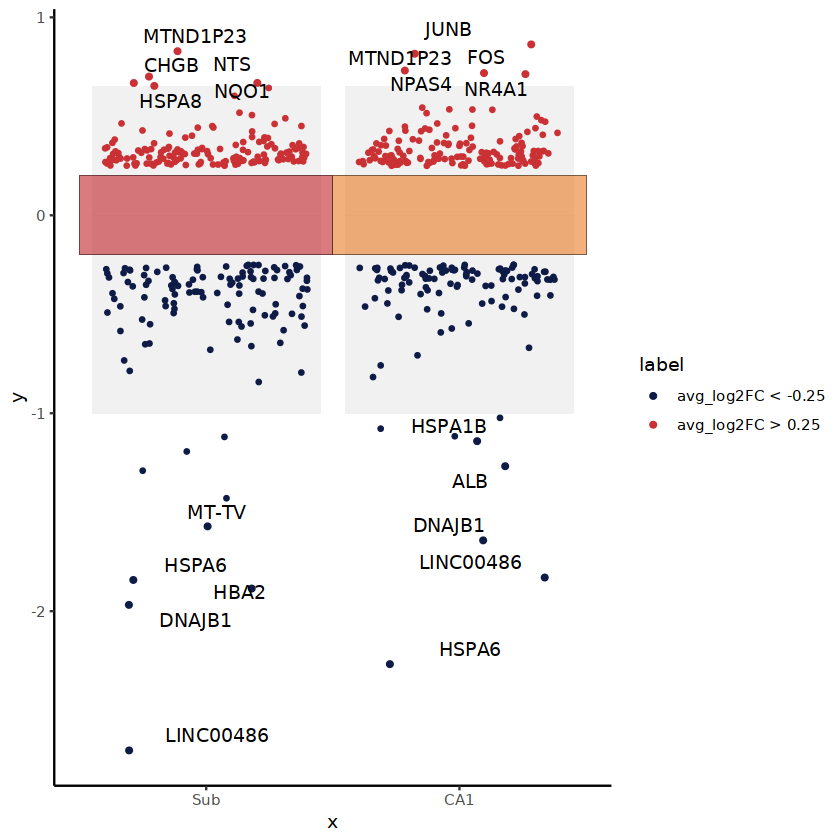

In [5]:

# 读取数据
setwd("/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/03.AD_vs_Con")
de = readRDS('01.bin.del_noSub.AD-vs-Con.allgenes.250224.rds')
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
sig.markers = de[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & abs(de$avg_log2FC)>logFCfilter),]
sig.markers$up.down = 'up'
sig.markers$up.down[which(sig.markers$avg_log2FC<0)] = 'down'
df = sig.markers#[which(sig.markers$up.down =='up'),]

df$cluster <- factor(df$cluster, levels = c("Sub", "CA1"))
df = df[order(df$cluster),]

# 添加显著性标签
df$label <- ifelse(df$avg_log2FC > 0.25, "avg_log2FC > 0.25", "avg_log2FC < -0.25")

# 获取每个cluster中表达差异最显著的10个基因（前5个最高和后5个最低）
top10.list <- list()
top10sig <- data.frame()
for (i in unique(df$cluster)) {
  top_pos <- filter(df, cluster == i) %>% distinct(gene, .keep_all = T) %>% top_n(5, avg_log2FC)
  top_neg <- filter(df, cluster == i) %>% distinct(gene, .keep_all = T) %>% top_n(5, -avg_log2FC)
  top10.list[[i]] <- rbind(top_pos, top_neg)
  top10sig <- rbind(top10sig, top10.list[[i]])
}

# 标记Top10的差异基因
df$size <- 1
df$size[which(paste0(df$cluster, "-", df$gene) %in% paste0(top10sig$cluster, "-", top10sig$gene))] <- 2

# 提取非Top10的基因表格
dt <- filter(df, size == 1)

# 绘制每个Cluster Top10以外基因的散点火山图
p <- ggplot(dt, aes(x = cluster, y = avg_log2FC, color = label)) +
  geom_jitter(size = 0.85, width = 0.4) +
  scale_color_manual(values = c("#0d1b46", "#ca3135")) +
  theme(axis.text = element_text(size = 15)) +
  scale_x_discrete(limits = c("Sub", "CA1"))  # 设置x轴顺序

# 叠加每个Cluster Top10基因散点
p <- p + geom_jitter(data = top10sig, aes(x = cluster, y = avg_log2FC, color = label), size = 1.2, width = 0.4)

# 绘制背景柱
dfbar <- data.frame(x = c("Sub", "CA1"), y = c(0.65, 0.65))
dfbar1 <- data.frame(x = c("Sub", "CA1"), y = c(-1, -1))
p1 <- ggplot() +
  geom_col(data = dfbar, aes(x = x, y = y), fill = "#dcdcdc", alpha = 0.4) +
  geom_col(data = dfbar1, aes(x = x, y = y), fill = "#dcdcdc", alpha = 0.4) +
  scale_x_discrete(limits = c("Sub", "CA1"))  # 设置x轴顺序

# 叠加散点图和背景柱
p2 <- p1 +
  geom_jitter(data = dt, aes(x = cluster, y = avg_log2FC, color = label), size = 0.85, width = 0.4) +
  geom_jitter(data = top10sig, aes(x = cluster, y = avg_log2FC, color = label), size = 1.2, width = 0.4) +
  scale_color_manual(values = c("#0d1b46", "#ca3135")) +
  theme(axis.text = element_text(size = 15))

# 添加cluster色块标签
dfcol <- data.frame(x = c("Sub", "CA1"), y = 0, label = c("Sub", "CA1"))
mycol <- cols[c("Sub","CA1")]  # 替换为您选择的颜色
p3 <- p2 + geom_tile(data = dfcol, aes(x = x, y = y), height = 0.4, color = "black", fill = mycol, alpha = 0.6, show.legend = F)

# 添加geneID标签
p4 <- p3 + geom_text_repel(data = top10sig, aes(x = cluster, y = avg_log2FC, label = gene), force = 1.2, arrow = arrow(length = unit(0.008, "npc"), type = "open", ends = "last"))

# 美化主题
p5 <- p4 + theme(axis.title.x = element_text(size = 25))+theme_classic()

# 显示图表
print(p5)

### co-expression modules of DEGs clustered by hdWGCNA

In [ ]:
PlotDendrogram(seurat_obj, main='INH hdWGCNA Dendrogram')

### Module score

In [ ]:
# M2:


    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


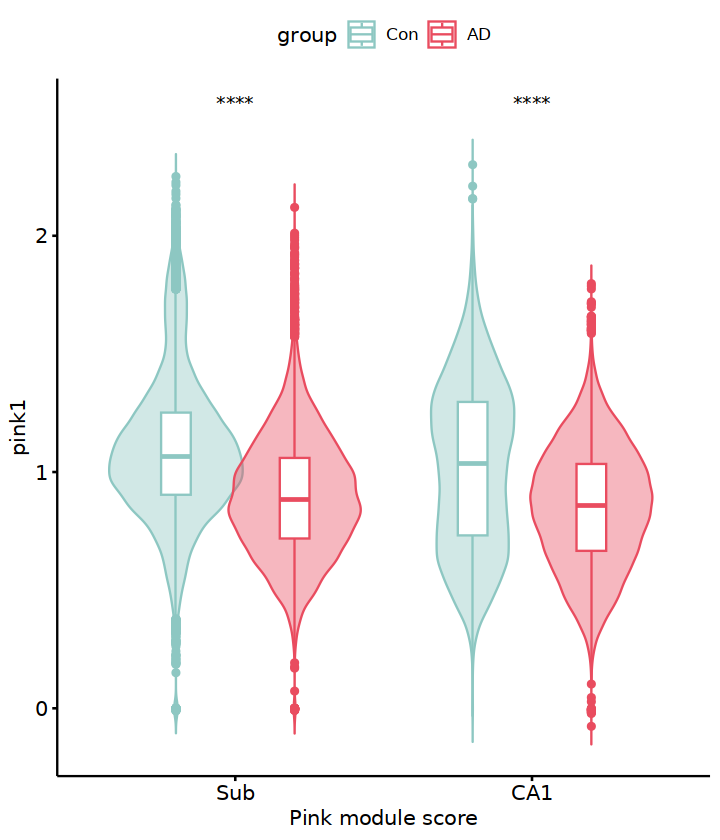

In [16]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='pink',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'pink' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "pink1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Pink module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y = pink1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$pink1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/pink1.pdf", height = 5, width = 7)


In [ ]:
# M5:

In [ ]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='green',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'green' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "green1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Green module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y = green1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$green1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/green1.pdf", height = 5, width = 7)
